In [18]:
%cd /home/ytee/test/trade_bot/

from src.csv.msci import MSCI
import numpy as np
from finagg.fred.api import CategorySeries, SeriesObservations,SeriesCategories,Tags
import pandas as pd
so = SeriesObservations()
sc = SeriesCategories()
ret= []

def get_series(eventid):
    metadata = sc.get(eventid)
    eclass = metadata.iloc[-1]['name']
    df = so.get(eventid )[['series_id', 'value', 'date']]
    df.columns= ['event', 'actual', 'datetime']
    df['eclass'] = eclass
    df['datetime'] = pd.to_datetime(df.datetime)
    return df



app = MSCI()
data = app.get_all_msci_codes()

/home/ytee/test/trade_bot/venv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ytee/test/trade_bot


<Axes: xlabel='date'>

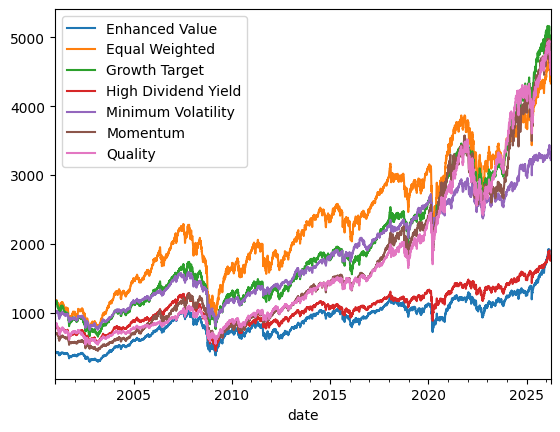

In [19]:
xx = app.get_all('World')
xx.plot()


<Axes: xlabel='date'>

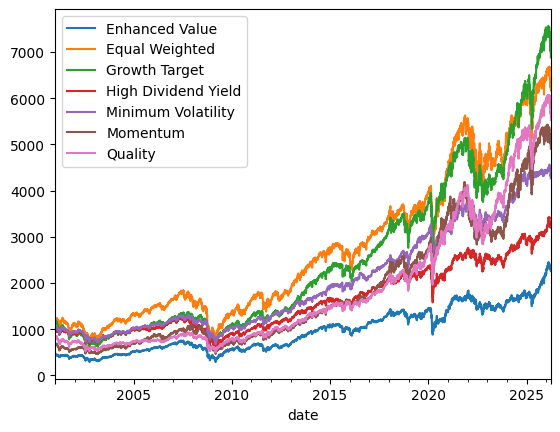

In [20]:
xx = app.get_all('US')
xx.plot()

In [22]:
us10yr=  get_series('DGS10').set_index('datetime')['actual']
us2yr=  get_series('DGS2').set_index('datetime')['actual']
us3mo = get_series('DGS3MO').set_index('datetime')['actual']
df = pd.concat([
    us10yr.rename('y10'),
    us2yr.rename('y2'),
    us3mo.rename('y3m')
], axis=1).dropna()

window = 60
df['d_short'] = df['y2'].diff()   # short-end (policy driven)
df['d_long']  = df['y10'].diff()  # long-end (growth/inflation)
# z-score both legs
df['z_short'] = (df['d_short'] - df['d_short'].rolling(window).mean()) / df['d_short'].rolling(window).std()
df['z_long']  = (df['d_long']  - df['d_long'].rolling(window).mean())  / df['d_long'].rolling(window).std()

def pos(x): return np.maximum(x, 0)
def neg(x): return np.maximum(-x, 0)

# Correct regime construction
df['bear_flat']  = pos(df['z_short']) * neg(df['z_long'] - df['z_short'])   # short ↑ more
df['bear_steep'] = pos(df['z_long'] - df['z_short']) * pos(df['z_short'])   # long ↑ more

df['bull_flat']  = neg(df['z_long']) * neg(df['z_long'] - df['z_short'])    # long ↓ more
df['bull_steep'] = neg(df['z_short']) * pos(df['z_long'] - df['z_short'])   # short ↓ more


/tmp/ipykernel_2272285/274606476.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  msci_monthly = xx.resample('M').last()
/tmp/ipykernel_2272285/274606476.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  yield_monthly = df[['y10', 'y2', 'y3m']].resample('M').last().dropna()


regime,bear_flat,bear_steep,bull_flat,bull_steep
Enhanced Value,0.85,1.02,0.32,0.41
Equal Weighted,0.88,1.00,0.11,0.58
Growth Target,0.93,0.95,0.08,0.73
High Dividend Yield,0.86,0.59,0.11,0.25
Minimum Volatility,0.97,0.57,0.05,0.43
Momentum,1.09,0.83,-0.01,1.03
Quality,1.02,0.59,0.26,0.83


regime,bear_flat,bear_steep,bull_flat,bull_steep
Enhanced Value,63.9,58.7,58.4,60.3
Equal Weighted,61.4,57.1,58.4,62.8
Growth Target,63.9,60.3,63.6,64.1
High Dividend Yield,65.1,57.1,51.9,62.8
Minimum Volatility,69.9,57.1,55.8,61.5
Momentum,68.7,58.7,54.5,61.5
Quality,66.3,58.7,59.7,64.1


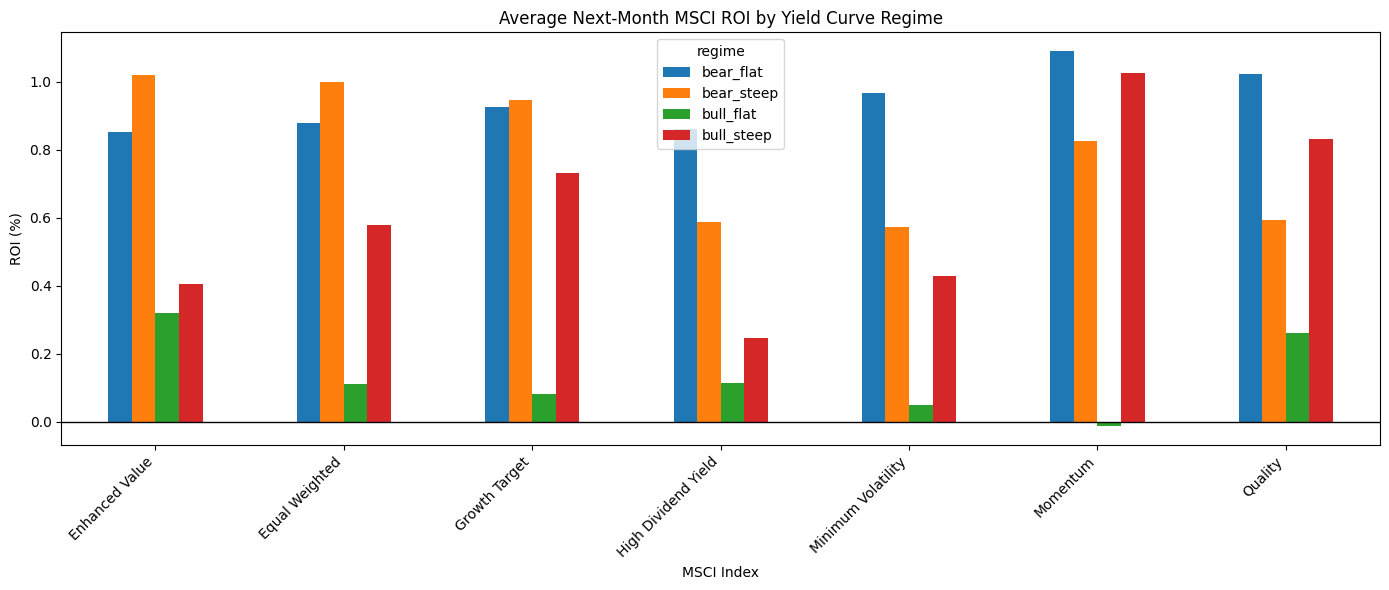

In [27]:
import matplotlib.pyplot as plt

msci_monthly = xx.resample('M').last()
msci_roi_1m = msci_monthly.pct_change().shift(-1)

yield_monthly = df[['y10', 'y2', 'y3m']].resample('M').last().dropna()
yield_monthly['d_short'] = yield_monthly['y2'].diff()
yield_monthly['d_long'] = yield_monthly['y10'].diff()

window = 12
yield_monthly['z_short'] = (yield_monthly['d_short'] - yield_monthly['d_short'].rolling(window).mean()) / yield_monthly['d_short'].rolling(window).std()
yield_monthly['z_long'] = (yield_monthly['d_long'] - yield_monthly['d_long'].rolling(window).mean()) / yield_monthly['d_long'].rolling(window).std()

def pos(x): return np.maximum(x, 0)
def neg(x): return np.maximum(-x, 0)

yield_monthly['bear_flat'] = pos(yield_monthly['z_short']) * neg(yield_monthly['z_long'] - yield_monthly['z_short'])
yield_monthly['bear_steep'] = pos(yield_monthly['z_long'] - yield_monthly['z_short']) * pos(yield_monthly['z_short'])
yield_monthly['bull_flat'] = neg(yield_monthly['z_long']) * neg(yield_monthly['z_long'] - yield_monthly['z_short'])
yield_monthly['bull_steep'] = neg(yield_monthly['z_short']) * pos(yield_monthly['z_long'] - yield_monthly['z_short'])

regime_cols = ['bear_flat', 'bear_steep', 'bull_flat', 'bull_steep']
regime_score = yield_monthly[regime_cols].dropna().copy()
regime = regime_score.idxmax(axis=1).rename('regime')
regime[regime_score.max(axis=1).eq(0)] = np.nan

analysis = msci_roi_1m.join(regime, how='inner').dropna(subset=['regime'])
avg_roi = analysis.groupby('regime')[msci_roi_1m.columns].mean().T * 100
hit_ratio = analysis.groupby('regime')[msci_roi_1m.columns].apply(lambda x: x.gt(0).mean()).T * 100

display(avg_roi.round(2))
display(hit_ratio.round(1))

ax = avg_roi.plot(kind='bar', figsize=(14, 6))
ax.set_title('Average Next-Month MSCI ROI by Yield Curve Regime')
ax.set_ylabel('ROI (%)')
ax.set_xlabel('MSCI Index')
ax.axhline(0, color='black', linewidth=1)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
